# Fashion-MNIST Feedforward Neural Network

## Project Setup

The goal here is to test a feedforward neural network classifier.


## Imports

This section imports the libraries used for loading the dataset, preparing the data, training the neural network, and evaluating the results.


In [1]:
# Imports and random seed setup
import os
import gzip
import struct
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

seed = 1234
np.random.seed(seed)

## Loading Fashion-MNIST

In [6]:
DATA_DIR = "../data/fashion"

label_names = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

def load_idx_images(path):
    with gzip.open(path, "rb") as f:
        _, n, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(n, rows, cols)

def load_idx_labels(path):
    with gzip.open(path, "rb") as f:
        _, n = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

X_train_full_img = load_idx_images(
    f"{DATA_DIR}/train-images-idx3-ubyte.gz"
)

y_train_full = load_idx_labels(
    f"{DATA_DIR}/train-labels-idx1-ubyte.gz"
)

X_test_img = load_idx_images(
    f"{DATA_DIR}/t10k-images-idx3-ubyte.gz"
)

y_test = load_idx_labels(
    f"{DATA_DIR}/t10k-labels-idx1-ubyte.gz"
)

print("Training images:", X_train_full_img.shape)
print("Test images:", X_test_img.shape)

Training images: (60000, 28, 28)
Test images: (10000, 28, 28)


## Quick Dataset Exploration

Before training the model, display one example from each of the ten clothing classes. 


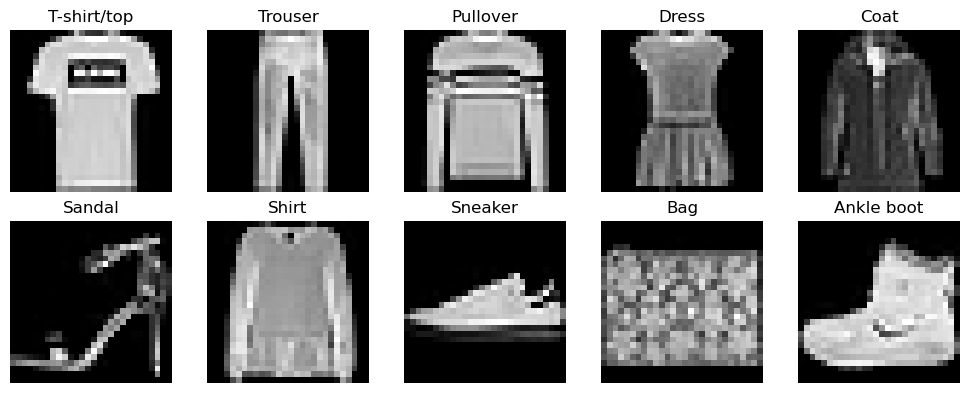

In [8]:
plt.figure(figsize=(10, 4))
for label in range(10):
    idx = np.where(y_train_full == label)[0][0]
    plt.subplot(2, 5, label + 1)
    plt.imshow(X_train_full_img[idx], cmap="gray")
    plt.title(label_names[label])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Preparing the Train, Validation, and Test Sets

The original training set is split into training and validation data so different hyperparameter settings can be compared before touching the test set.


In [10]:
# Flatten images and normalize pixel values
X_train_full = X_train_full_img.reshape(X_train_full_img.shape[0], -1).astype(np.float32) / 255.0
X_test = X_test_img.reshape(X_test_img.shape[0], -1).astype(np.float32) / 255.0

# Split original training data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=seed,
    stratify=y_train_full,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (48000, 784)
X_val: (12000, 784)
X_test: (10000, 784)


## Training Feedforward Neural Networks

The models below compare:

- one smaller hidden layer
- one larger hidden layer
- two hidden layers

In [12]:
parameter_settings = [
    {"name": "64 neurons", "hidden_layer_sizes": (64,)},
    {"name": "128 neurons", "hidden_layer_sizes": (128,)},
    {"name": "128-64 neurons", "hidden_layer_sizes": (128, 64)},
]

results = []

for params in parameter_settings:
    print("Training:", params["name"])

    clf = MLPClassifier(
        hidden_layer_sizes=params["hidden_layer_sizes"],
        learning_rate_init=0.001,
        max_iter=25,
        random_state=seed
    )

    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    val_acc = accuracy_score(y_val, clf.predict(X_val))

    results.append({
        "model": params["name"],
        "hidden_layer_sizes": params["hidden_layer_sizes"],
        "train_accuracy": train_acc,
        "validation_accuracy": val_acc
    })

results_df = pd.DataFrame(results)
results_df

Training: 64 neurons


C:\Users\16267\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: 128 neurons


C:\Users\16267\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


Training: 128-64 neurons


C:\Users\16267\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,hidden_layer_sizes,train_accuracy,validation_accuracy
0,64 neurons,"(64,)",0.919479,0.882250
1,128 neurons,"(128,)",0.931000,0.886083
2,128-64 neurons,"(128, 64)",0.938708,0.890917


## Choosing the Best Model

Selected the model with the highest validation accuracy. The test set is evaluated only once here to give a final estimate of performance.


In [14]:
best_index = results_df["validation_accuracy"].idxmax()
best_model_name = results_df.loc[best_index, "model"]

print("Best model:", best_model_name)
print(results_df.loc[best_index])

# retrain the best architecture on the training data
if best_model_name == "64 neurons":
    best_model = MLPClassifier(
        hidden_layer_sizes=(64,),
        learning_rate_init=0.001,
        max_iter=25,
        random_state=seed
    )

elif best_model_name == "128 neurons":
    best_model = MLPClassifier(
        hidden_layer_sizes=(128,),
        learning_rate_init=0.001,
        max_iter=25,
        random_state=seed
    )

else:
    best_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        learning_rate_init=0.001,
        max_iter=25,
        random_state=seed
    )

best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print("Final test accuracy:", test_acc)

Best model: 128-64 neurons
model                  128-64 neurons
hidden_layer_sizes          (128, 64)
train_accuracy               0.938708
validation_accuracy          0.890917
Name: 2, dtype: object


C:\Users\16267\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


Final test accuracy: 0.889
